# Plot de Captura Real e Virtual

Este notebook seleciona a captura diretamente do que ja foi exportado em `output/robot_emotions_virtual_imu`.
O plot de cima mostra o IMU real e o de baixo mostra o IMU virtual.

In [14]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

CHANNEL_GROUP_TO_LABELS = {
    "acc": ("ax", "ay", "az"),
    "gyro": ("gx", "gy", "gz"),
}
VIRTUAL_GROUP_TO_KEY = {
    "acc": "acc",
    "gyro": "gyro",
}
GROUP_TO_UNIT = {
    "acc": "m/s^2",
    "gyro": "rad/s",
}
AXIS_COLORS = {
    "x": "tab:red",
    "y": "tab:green",
    "z": "tab:blue",
}
SENSOR_LINESTYLES = ("-", "--", ":", "-.")


def find_project_root():
    candidate_roots = []
    cwd = Path.cwd().resolve()
    candidate_roots.extend([cwd, *cwd.parents])
    candidate_roots.append(Path("/home/henriquesouza/IMUGPT"))

    seen = set()
    for candidate in candidate_roots:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "pose_module").exists() and (candidate / "output" / "robot_emotions_virtual_imu").exists():
            return candidate

    raise RuntimeError(
        "Nao encontrei a raiz do projeto. Abra o notebook dentro do repo IMUGPT."
    )


def build_exported_capture_table(output_root):
    rows = []
    for metadata_path in sorted(output_root.rglob("metadata.json")):
        clip_dir = metadata_path.parent
        pose_dir = clip_dir / "pose"
        real_npz_path = clip_dir / "imu.npz"
        virtual_npz_path = pose_dir / "virtual_imu.npz"
        if not real_npz_path.exists() or not virtual_npz_path.exists():
            continue

        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        rows.append(
            {
                "clip_id": metadata["clip_id"],
                "domain": metadata["domain"],
                "user_id": int(metadata["user_id"]),
                "tag_number": int(metadata["tag_number"]),
                "take_id": metadata.get("take_id"),
                "emotion": metadata["labels"].get("emotion"),
                "action": metadata["labels"].get("action"),
                "stimulus": metadata["labels"].get("stimulus"),
                "clip_dir": str(clip_dir.resolve()),
                "pose_dir": str(pose_dir.resolve()),
            }
        )

    frame = pd.DataFrame(rows)
    if frame.empty:
        raise RuntimeError(
            f"Nenhuma captura pronta para plot foi encontrada em {output_root}."
        )

    return frame.sort_values(
        ["domain", "user_id", "tag_number", "take_id", "clip_id"],
        kind="stable",
    ).reset_index(drop=True)


def select_capture_row(captures_df, *, clip_id=None, domain=None, user_id=None, tag_number=None, take_id=None):
    frame = captures_df.copy()
    if clip_id not in (None, ""):
        frame = frame[frame["clip_id"] == str(clip_id)]
    else:
        if domain is None or user_id is None or tag_number is None:
            raise ValueError("Preencha CLIP_ID ou informe DOMAIN, USER_ID e TAG_NUMBER.")
        frame = frame[
            (frame["domain"] == str(domain))
            & (frame["user_id"] == int(user_id))
            & (frame["tag_number"] == int(tag_number))
        ]
        if take_id not in (None, ""):
            frame = frame[frame["take_id"] == take_id]

    if frame.empty:
        raise ValueError(
            "Nenhuma captura encontrada no output para os parametros escolhidos. "
            "Consulte CAPTURES_DF para ver os valores disponiveis."
        )
    if len(frame) > 1:
        raise ValueError(
            "Mais de uma captura encontrada. Preencha TAKE_ID ou use CLIP_ID."
        )
    return frame.iloc[0]


def load_real_capture(clip_dir):
    clip_dir = Path(clip_dir)
    metadata = json.loads((clip_dir / "metadata.json").read_text(encoding="utf-8"))
    with np.load(clip_dir / "imu.npz", allow_pickle=True) as payload:
        return {
            "timestamps_sec": np.asarray(payload["timestamps_sec"], dtype=np.float32),
            "imu": np.asarray(payload["imu"], dtype=np.float32),
            "sensor_names": list(metadata["imu"]["sensor_names"]),
            "channel_axis_order": list(metadata["imu"]["channel_axis_order"]),
            "metadata": metadata,
        }


def load_virtual_capture(pose_dir):
    pose_dir = Path(pose_dir)
    with np.load(pose_dir / "virtual_imu.npz", allow_pickle=True) as payload:
        return {
            "timestamps_sec": np.asarray(payload["timestamps_sec"], dtype=np.float32),
            "acc": np.asarray(payload["acc"], dtype=np.float32),
            "gyro": np.asarray(payload["gyro"], dtype=np.float32),
            "sensor_names": [str(value) for value in np.asarray(payload["sensor_names"]).tolist()],
            "fps": float(np.asarray(payload["fps"]).item()),
            "clip_id": str(np.asarray(payload["clip_id"]).item()),
            "source": str(np.asarray(payload["source"]).item()),
        }


def resolve_selected_sensors(requested_sensors, available_sensors):
    if requested_sensors is None:
        return list(available_sensors)
    selected_sensors = [str(sensor_name) for sensor_name in requested_sensors]
    missing_sensors = [sensor_name for sensor_name in selected_sensors if sensor_name not in available_sensors]
    if len(missing_sensors) > 0:
        raise ValueError(f"Sensores nao encontrados: {missing_sensors}")
    return selected_sensors


def apply_time_range(timestamps_sec, values, time_range_sec):
    if time_range_sec is None:
        return timestamps_sec, values
    start_sec, end_sec = time_range_sec
    mask = (timestamps_sec >= float(start_sec)) & (timestamps_sec <= float(end_sec))
    return timestamps_sec[mask], values[mask]


def plot_signal_block(
    ax,
    *,
    timestamps_sec,
    values,
    sensor_names,
    selected_sensors,
    component_labels,
    title,
    unit,
    time_range_sec=None,
    line_width=1.5,
):
    timestamps_plot, values_plot = apply_time_range(timestamps_sec, values, time_range_sec)
    if values_plot.shape[0] == 0:
        raise ValueError("TIME_RANGE_SEC nao retornou amostras.")

    for sensor_order, sensor_name in enumerate(selected_sensors):
        sensor_index = sensor_names.index(sensor_name)
        line_style = SENSOR_LINESTYLES[sensor_order % len(SENSOR_LINESTYLES)]
        for component_index, component_label in enumerate(component_labels):
            axis_name = component_label[-1]
            ax.plot(
                timestamps_plot,
                values_plot[:, sensor_index, component_index],
                label=f"{sensor_name} / {component_label}",
                color=AXIS_COLORS[axis_name],
                linestyle=line_style,
                linewidth=line_width,
            )

    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))


PROJECT_ROOT = Path(".")
OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu_cal"
CAPTURES_DF = build_exported_capture_table(OUTPUT_ROOT)


In [15]:
CAPTURES_DF[["clip_id", "domain", "user_id", "tag_number", "take_id", "emotion", "action"]]

,clip_id,domain,user_id,tag_number,take_id,emotion,action
0,robot_emotions_10ms_u02_tag01,10ms,2,1,None,Neutrality,Standing


In [16]:
# Se CLIP_ID estiver preenchido, ele tem prioridade.
CLIP_ID = "robot_emotions_10ms_u02_tag01"

# Use estas variaveis somente se quiser selecionar sem CLIP_ID.
DOMAIN = "10ms"
USER_ID = 2
TAG_NUMBER = 5
TAKE_ID = None

# Parametros do plot
SIGNAL_GROUP = "acc"  # "acc" ou "gyro"
SENSOR_NAMES = ["right_forearm"]  # None para todos os sensores
TIME_RANGE_SEC = None  # Exemplo: (0, 20)
FIGSIZE = (16, 10)
LINE_WIDTH = 1.5


,clip_id,domain,user_id,tag_number,take_id,emotion,action,signal_group,selected_sensors,real_frames,virtual_frames
0,robot_emotions_10ms_u02_tag01,10ms,2,1,None,Neutrality,Standing,acc,right_forearm,11590,2086


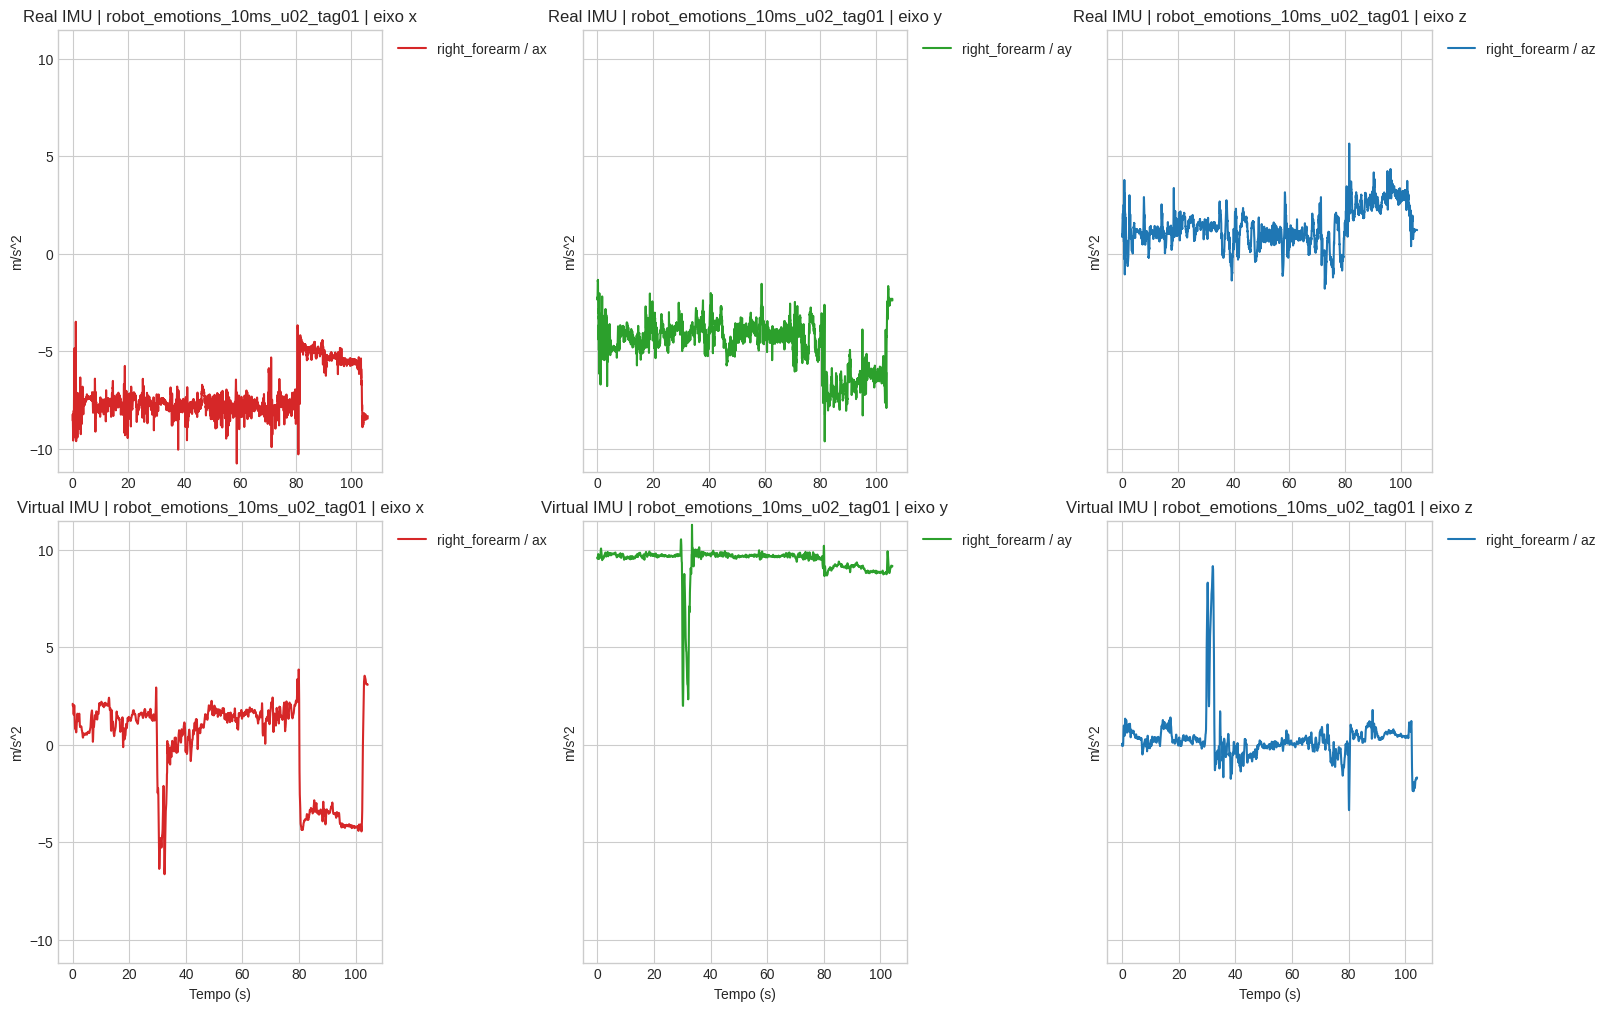

In [17]:
if SIGNAL_GROUP not in CHANNEL_GROUP_TO_LABELS:
    raise ValueError("SIGNAL_GROUP deve ser 'acc' ou 'gyro'.")

capture_row = select_capture_row(
    CAPTURES_DF,
    clip_id=CLIP_ID,
    domain=DOMAIN,
    user_id=USER_ID,
    tag_number=TAG_NUMBER,
    take_id=TAKE_ID,
)

clip_dir = Path(capture_row["clip_dir"])
pose_dir = Path(capture_row["pose_dir"])

real_data = load_real_capture(clip_dir)
virtual_data = load_virtual_capture(pose_dir)

selected_sensors = resolve_selected_sensors(SENSOR_NAMES, real_data["sensor_names"])
selected_sensors = resolve_selected_sensors(selected_sensors, virtual_data["sensor_names"])

component_labels = CHANNEL_GROUP_TO_LABELS[SIGNAL_GROUP]
real_slice = slice(0, 3) if SIGNAL_GROUP == "acc" else slice(3, 6)
real_values = real_data["imu"][:, :, real_slice]
virtual_values = virtual_data[VIRTUAL_GROUP_TO_KEY[SIGNAL_GROUP]]

summary_row = {
    "clip_id": capture_row["clip_id"],
    "domain": capture_row["domain"],
    "user_id": int(capture_row["user_id"]),
    "tag_number": int(capture_row["tag_number"]),
    "take_id": capture_row["take_id"],
    "emotion": capture_row["emotion"],
    "action": capture_row["action"],
    "signal_group": SIGNAL_GROUP,
    "selected_sensors": ", ".join(selected_sensors),
    "real_frames": int(real_values.shape[0]),
    "virtual_frames": int(virtual_values.shape[0]),
}
display(pd.DataFrame([summary_row]))

# Usa a mesma janela de tempo para calcular limites globais de y.
_, real_values_for_scale = apply_time_range(
    real_data["timestamps_sec"],
    real_values,
    TIME_RANGE_SEC,
)
_, virtual_values_for_scale = apply_time_range(
    virtual_data["timestamps_sec"],
    virtual_values,
    TIME_RANGE_SEC,
)

if real_values_for_scale.shape[0] == 0 or virtual_values_for_scale.shape[0] == 0:
    raise ValueError("TIME_RANGE_SEC nao retornou amostras para comparar real e virtual.")

y_min = float(min(real_values_for_scale.min(), virtual_values_for_scale.min()))
y_max = float(max(real_values_for_scale.max(), virtual_values_for_scale.max()))
if y_min == y_max:
    y_min -= 1e-6
    y_max += 1e-6

fig, axes = plt.subplots(
    2, 3, figsize=FIGSIZE, sharex=False, sharey=True, constrained_layout=True
)

for component_index, component_label in enumerate(component_labels):
    axis_name = component_label[-1]
    real_component_values = real_values[:, :, component_index : component_index + 1]
    virtual_component_values = virtual_values[:, :, component_index : component_index + 1]

    plot_signal_block(
        axes[0, component_index],
        timestamps_sec=real_data["timestamps_sec"],
        values=real_component_values,
        sensor_names=real_data["sensor_names"],
        selected_sensors=selected_sensors,
        component_labels=(component_label,),
        title=f"Real IMU | {capture_row['clip_id']} | eixo {axis_name}",
        unit=GROUP_TO_UNIT[SIGNAL_GROUP],
        time_range_sec=TIME_RANGE_SEC,
        line_width=LINE_WIDTH,
    )

    plot_signal_block(
        axes[1, component_index],
        timestamps_sec=virtual_data["timestamps_sec"],
        values=virtual_component_values,
        sensor_names=virtual_data["sensor_names"],
        selected_sensors=selected_sensors,
        component_labels=(component_label,),
        title=f"Virtual IMU | {capture_row['clip_id']} | eixo {axis_name}",
        unit=GROUP_TO_UNIT[SIGNAL_GROUP],
        time_range_sec=TIME_RANGE_SEC,
        line_width=LINE_WIDTH,
    )

    axes[0, component_index].set_ylim(y_min, y_max)
    axes[1, component_index].set_ylim(y_min, y_max)
    axes[1, component_index].set_xlabel("Tempo (s)")

plt.show()
